<a href="https://colab.research.google.com/github/sakshibhutekar/Ml-Models/blob/main/Regression/Ridge%20and%20Lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

In [7]:
df = fetch_california_housing()
dataset = pd.DataFrame(df.data)
dataset.describe()

,0,1,2,3,4,5,6,7
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [8]:
dataset.columns = df.feature_names
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
# independent and dependent variable
X = dataset
y = df.target

In [10]:
# train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42)

In [ ]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit on training set only.
scaler.fit(X_train)
# Apply transform to both the training set and the test set.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
# Cross validation
from sklearn.model_selection import cross_val_score

In [ ]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
mse = cross_val_score(reg, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
mean_mse = np.mean(mse)
print(mean_mse)

-0.5229191767487006


In [ ]:
reg_pred = reg.predict(X_test)

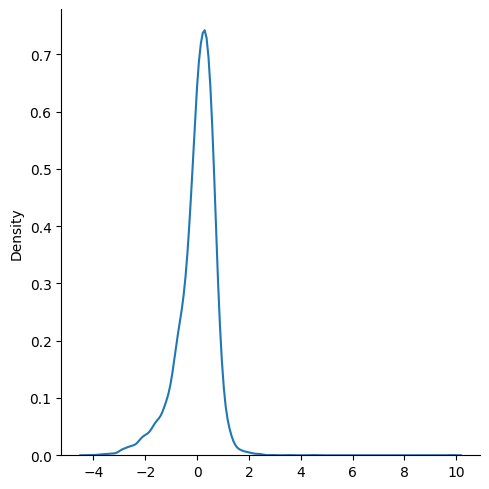

In [ ]:
#visualiztion
import seaborn as sns
sns.displot(reg_pred-y_test,kind='kde')

In [ ]:
from sklearn.metrics import r2_score
score= r2_score(y_test,reg_pred)
print(score)
# r2= 0.60

0.5981562649706543


# **Ridge and Lasso algorithms**

In [2]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [17]:
#Ridge Algorithm
ridge_rege= Ridge()

In [4]:
ridge_rege

Ridge()

In [20]:
parameters= {'alpha': [6,7,8,9,10,20,30,40,50,90]}
ridgecv= GridSearchCV(ridge_rege, parameters, scoring='neg_mean_squared_error', cv=5)
ridgecv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [6, 7, 8, 9, 10, 20, 30, 40, 50, 90]},
             scoring='neg_mean_squared_error')

In [21]:
print(ridgecv.best_params_)
print(ridgecv.best_score_)


{'alpha': 6}
-0.5229235529094245


In [22]:
ridge_pred= ridgecv.predict(X_test)

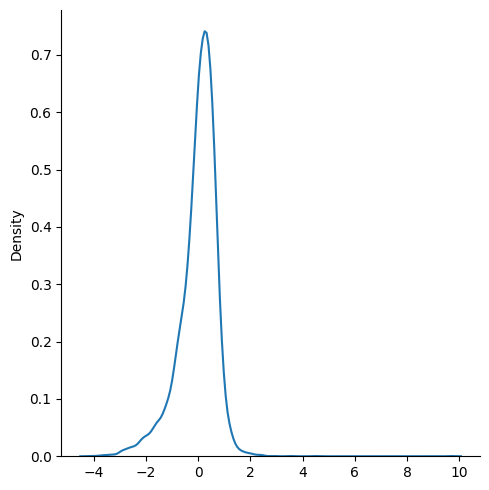

In [23]:
import seaborn as sns
sns.displot(ridge_pred-y_test,kind='kde')

In [18]:
#Lasso Algorithm
lasso_rege= Lasso()

In [19]:
parameters= {'alpha': [1,2,3,4,5,6,7,8,9,10,20,30,40,50,90]}
lassocv= GridSearchCV(lasso_rege, parameters, scoring='neg_mean_squared_error', cv=5)
lassocv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40,
                                   50, 90]},
             scoring='neg_mean_squared_error')

In [25]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 1}
-0.9494409146064872


In [26]:
lasso_pred= lassocv.predict(X_test)

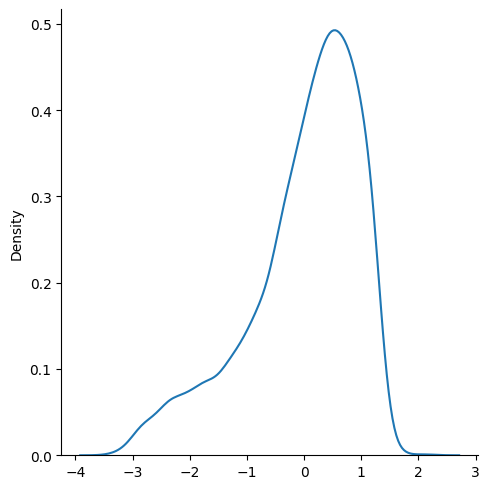

In [28]:
sns.displot(lasso_pred-y_test,kind='kde')